In [4]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
from typing import Optional, List, Dict, Any  # Import typing module with commonly used types
#import pathlib
#import sys

#proj_src = pathlib.Path().resolve().parent.parent / "motec-ld-export-ui" / "motec-to-csv" / "src"
#sys.path.append(str(proj_src))
#from motec_converter import parse_race_data, to_pandas
#sys.path.remove(str(proj_src))

In [5]:
import sys, pathlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
def process_and_compute_efficiency(dyno_files, motec_files, target_torque=150,
                                   rpm_diff_tol=None, rolling_window=3, plot=True):
    """
    Process dyno and MoTeC data and compute motor efficiency.
    
    Parameters:
    - dyno_df: DataFrame with dyno data indexed by run ID
    - motec_files: list of MoTeC file paths
    - dyno_ids: list of corresponding dyno IDs for each MoTeC file
    - target_torque: torque to filter by (Nm)
    - rpm_diff_tol: if given, only match points within ±rpm_diff_tol
    - rolling_window: window for rolling mean smoothing
    - plot: if True, generate scatter plot of efficiency vs RPM
    
    Returns:
    - combined_df: concatenated DataFrame with efficiency calculations
    """
    
    all_runs = []
    i= 1
    for motec_file, dyno_file in zip(motec_files, dyno_files):
        print(i)
        i+=1
        # --- Load dyno ---
        #print(f'Dyno_Data/{dyno_file}')
        cur_dyno_df = pd.read_csv(f'Dyno_Data/{dyno_file}')
        cur_dyno_df = cur_dyno_df.dropna(subset=['Axle Speed (rpm)', 'Axle Torque (Nm)'])

        cur_dyno_df['Calculated Motor RPM'] = cur_dyno_df['Axle Speed (rpm)'] * 38/11
        cur_dyno_df['Calculated Motor Torque'] = cur_dyno_df['Axle Torque (Nm)'] * 11/38
        
        
        rpm_min = cur_dyno_df["Calculated Motor RPM"].min()
        rpm_max = cur_dyno_df["Calculated Motor RPM"].max()
        
        # --- Load MoTeC ---
        #motec_df = motec_files
        motec_df = pd.read_csv(f'Motec_Data/CSV Export/{motec_file}', header=8, low_memory=False)
        motec_df= motec_df.iloc[1:].reset_index(drop=True)
        motec_df = motec_df.apply(pd.to_numeric, errors='coerce')
        voltage_col = 'Car.Data.Inverter.InverterDCVoltage'
        current_col = 'Car.Data.Inverter.InverterDCCurrent'
        motec_df['Battery Power (kW)'] = (motec_df[voltage_col] * motec_df[current_col] / (100000))
        
        if not (motec_df[current_col] > 0).any():
            print("WARNING: No positive DC current detected. Skipping.")
            continue

            

        #print(rpm_min, rpm_max)
        
        # Filter by RPM range and target torque
        motec_trim = motec_df[
            (motec_df["Car.Data.Motor.MotorRPM"] >= rpm_min) &
            (motec_df["Car.Data.Motor.MotorRPM"] <= rpm_max) &
            (motec_df['Car.Data.Inverter.InverterCalculatedTorque'] >= 150) &
            (motec_df['Battery Power (kW)'] > 1)
            ].copy()
        
        # Only keep monotonic increasing RPM
        motec_trim = motec_trim[motec_trim["Car.Data.Motor.MotorRPM"].diff() > 0]
        
        # Rolling mean smoothing
        motec_trim = motec_trim.rolling(rolling_window).mean().dropna()

        # --- NEW SAFETY CHECK ---
        # If motec_trim is empty, skip this file and move to the next one
        if motec_trim.empty:
            print(f"Skipping {motec_file}: No data matches target torque/RPM criteria.")
            continue
        
        # --- Nearest neighbor matching ---
        dyno_features = cur_dyno_df[['Calculated Motor RPM', 'Calculated Motor Torque']].to_numpy()
        #print(dyno_features)
        motec_features = motec_trim[['Car.Data.Motor.MotorRPM', 'Car.Data.Inverter.InverterCalculatedTorque']].to_numpy()

        scaler = StandardScaler()
        dyno_features_scaled = scaler.fit_transform(dyno_features)
        motec_features_scaled = scaler.transform(motec_features)
        
        #print(motec_features)
        nn = NearestNeighbors(n_neighbors=1)
        nn.fit(dyno_features_scaled)
        distances, indices = nn.kneighbors(motec_features_scaled)
        
        matched_dyno = cur_dyno_df.iloc[indices.flatten()].reset_index(drop=True)
        matched_motec = motec_trim.reset_index(drop=True)
        
        # Optional RPM difference filter
        if rpm_diff_tol is not None:
            rpm_diff = np.abs(matched_dyno['Calculated Motor RPM'] - matched_motec['Car.Data.Motor.MotorRPM'])
            keep = rpm_diff <= rpm_diff_tol
            matched_dyno = matched_dyno[keep].reset_index(drop=True)
            matched_motec = matched_motec[keep].reset_index(drop=True)
        
        # --- Compute efficiency ---
        matched_df = matched_motec.copy()
        matched_df['P_out'] = matched_dyno['Calculated Motor Torque'] * 2 * np.pi * matched_dyno['Calculated Motor RPM'] / 60 / 1000
        matched_df['P_in'] = matched_motec['Battery Power (kW)']
        matched_df['eff'] = matched_df['P_out'] / matched_df['P_in']
        
        
        all_runs.append(matched_df)
    
    # --- Combine all runs ---
    combined_df = pd.concat(all_runs, ignore_index=True)
    combined_df = combined_df[(combined_df['eff'] < 1) & (combined_df['eff'] >0)]  # sanity filter
    
    # --- Plot ---
    if plot and not combined_df.empty:
        x = combined_df['Car.Data.Motor.MotorRPM']
        y = combined_df['Car.Data.Inverter.InverterCalculatedTorque']
        z = combined_df['eff']

        # ---------------------------------------------------------
        # PLOT 1: True 3D Scatter Plot
        # ---------------------------------------------------------
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Color map based on efficiency
        sc = ax.scatter(x, y, z, c=z, cmap='RdYlGn', s=10, alpha=0.8)
        
        ax.set_xlabel("Motor RPM")
        ax.set_ylabel("Motor Torque (Nm)")
        ax.set_zlabel("Efficiency")
        ax.set_title("3D Motor Efficiency Scatter")
        fig.colorbar(sc, label="Efficiency", shrink=0.5)
        plt.show()

        # ---------------------------------------------------------
        # PLOT 2: 2D Contour "Island" Map (Industry Standard)
        # ---------------------------------------------------------
        plt.figure(figsize=(12, 8))
        
        # tricontourf interpolates the scattered data into a smooth heat map
        cntr = plt.tricontourf(x, y, z, levels=20, cmap='RdYlGn')
        
        plt.colorbar(cntr, label="Efficiency")
        plt.xlabel("Motor RPM")
        plt.ylabel("Motor Torque (Nm)")
        plt.title("Motor Efficiency Island Map")
        plt.grid(True, alpha=0.3)
        plt.show()
    
    return combined_df

In [7]:
from pathlib import Path


folder = Path("Dyno_Data")

csv_files = [f.name for f in folder.glob('*.csv')]

print(csv_files)

['speedramp3_pl70_manual_dhruv.csv', 'speedramp6_pl100_manual_dhruv.csv', 'speedramp9_pl130_manual_dhruv.csv', 'speedramp7_pl110_manual_dhruv.csv', 'speedramp12_pl160_maual_dhruv_failed.csv', 'speedramp4_pl80_manual_dhruv.csv', 'speedramp1_pl50_manual_dhruv.csv', 'speedramp13_pl167-1_manual_dhruv_failed.csv', 'speedramp8_pl120_manual_dhruv.csv', 'speedramp11_pl150_manual_dhruv.csv', 'speedramp2_pl60_manual_dhruv.csv', 'speedramp10_pl140_manual_dhruv.csv', 'speedramp5_pl90_manual_dhruv.csv']


In [8]:
import re
def extract_run_number(filename):
    return int(re.search(r"speedramp(\d+)", filename).group(1))

# filter out 13, then sort
sorted_dyno_files = sorted(
    [f for f in csv_files if extract_run_number(f) <= 12],
    key=extract_run_number
)

print(sorted_dyno_files[0])

speedramp1_pl50_manual_dhruv.csv


In [9]:
df_test = pd.read_csv(f'Dyno_Data/{sorted_dyno_files[0]}', index_col=0, parse_dates=True)
df_test

,Axle Torque (Nm),Axle Speed (rpm),Power (kW),TqC (Nm),Time (sec),Tailshaft Speed (rpm),Speed (km/h),Tacho [Rat] (rpm),Speed L (rpm),Tq L (Nm),Speed R (rpm),Axle Tq R (Nm),Comments
Run Name,,,,,,,,,,,,,
MUREV2025.0028,142.5,756.52,11.249,43.506,1.30,2958.0,58.025,2469.1,759.0,97.5,754.1,45.0,NaN
MUREV2025.0028,142.5,755.80,11.252,43.562,1.35,2955.2,57.967,2466.7,758.2,98.0,753.4,44.5,NaN
MUREV2025.0028,142.5,756.00,11.229,43.500,1.40,2956.0,57.931,2465.2,758.4,98.5,753.6,44.0,NaN
MUREV2025.0028,142.5,756.52,11.226,43.498,1.45,2958.0,57.917,2464.6,759.0,98.5,754.0,44.0,NaN
MUREV2025.0028,142.0,757.60,11.200,43.380,1.50,2962.2,57.938,2465.5,760.2,98.5,755.0,43.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
MUREV2025.0028,149.0,1418.40,22.021,45.523,14.90,5545.9,108.554,4619.4,1418.8,39.5,1418.0,109.5,NaN
MUREV2025.0028,149.0,1414.56,21.996,45.512,14.95,5530.9,108.454,4615.1,1415.8,39.5,1413.3,109.5,NaN
MUREV2025.0028,148.5,1403.56,21.851,45.357,15.00,5487.9,108.108,4600.4,1407.2,39.0,1399.9,109.5,NaN


In [10]:
folder = Path("Motec_Data/CSV Export")

csv_motec_files = [f.name for f in folder.glob('*.csv')]

print(csv_motec_files)

['dryno_morning_torquemapping_withshudderissue_4.csv', 'dryno_morning_torquemapping_withshudderissue_5.csv', 'dryno_morning_torquemapping_withshudderissue_7.csv', 'dryno_morning_torquemapping_withshudderissue_6.csv', 'dryno_morning_torquemapping_withshudderissue_2.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_11.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_10.csv', 'dryno_morning_torquemapping_withshudderissue_3.csv', 'dryno_morning_torquemapping_withshudderissue_1.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_12.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_3.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_2.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_1.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_5.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_4.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_6.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_7.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_9.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_8.csv']


In [11]:
def extract_num(f):
    return int(re.search(r"_(\d+)\.csv", f).group(1))

# filter + sort
motec_sorted = sorted(
    [f for f in csv_motec_files if "dyno_arvo" in f],
    key=extract_num
)

print(motec_sorted)

['dyno_arvo_shudderfix_andlowrpmspeedramp_1.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_2.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_3.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_4.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_5.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_6.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_7.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_8.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_9.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_10.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_11.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_12.csv']


1
Skipping dyno_arvo_shudderfix_andlowrpmspeedramp_2.csv: No data matches target torque/RPM criteria.
2
Skipping dyno_arvo_shudderfix_andlowrpmspeedramp_3.csv: No data matches target torque/RPM criteria.
3
Skipping dyno_arvo_shudderfix_andlowrpmspeedramp_4.csv: No data matches target torque/RPM criteria.
4
Skipping dyno_arvo_shudderfix_andlowrpmspeedramp_5.csv: No data matches target torque/RPM criteria.
5
6
Skipping dyno_arvo_shudderfix_andlowrpmspeedramp_7.csv: No data matches target torque/RPM criteria.
7
Skipping dyno_arvo_shudderfix_andlowrpmspeedramp_8.csv: No data matches target torque/RPM criteria.
8
Skipping dyno_arvo_shudderfix_andlowrpmspeedramp_9.csv: No data matches target torque/RPM criteria.
9
Skipping dyno_arvo_shudderfix_andlowrpmspeedramp_10.csv: No data matches target torque/RPM criteria.
10
Skipping dyno_arvo_shudderfix_andlowrpmspeedramp_11.csv: No data matches target torque/RPM criteria.
11


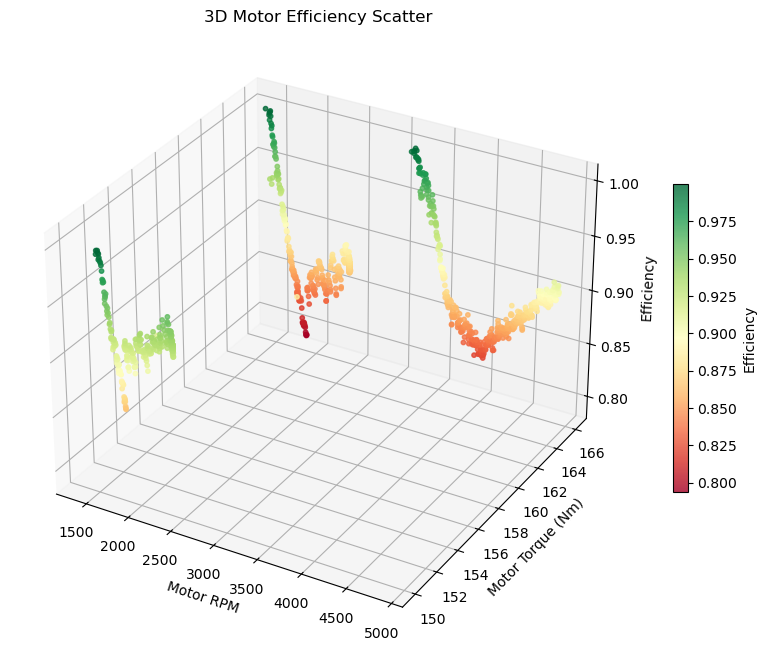

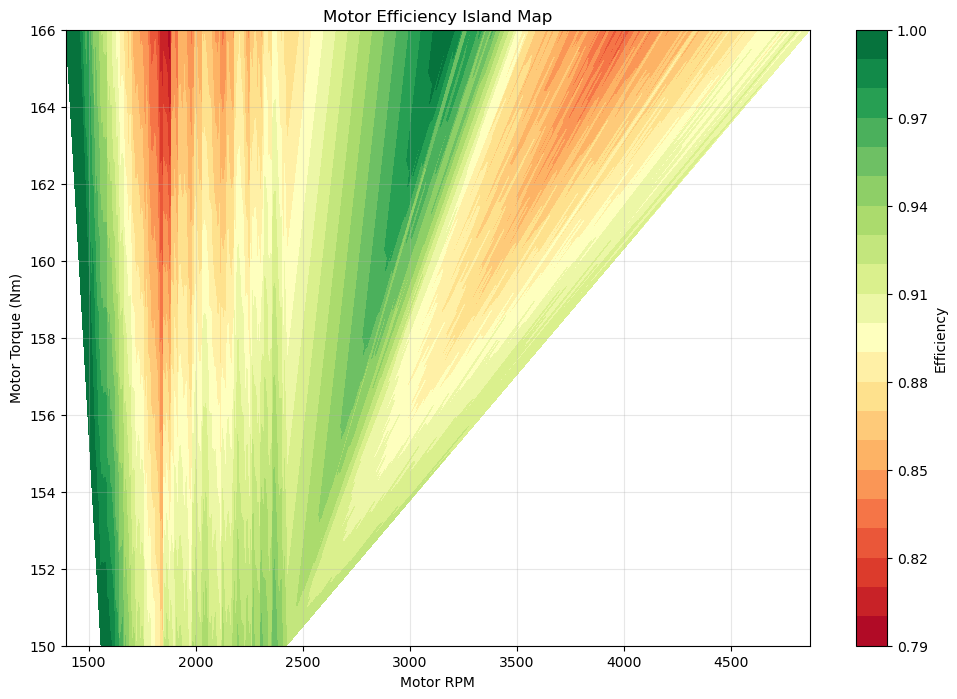

In [21]:
combined_df= process_and_compute_efficiency(sorted_dyno_files[1:], motec_sorted[1:], target_torque=10, rpm_diff_tol=None, rolling_window=3, plot=True)

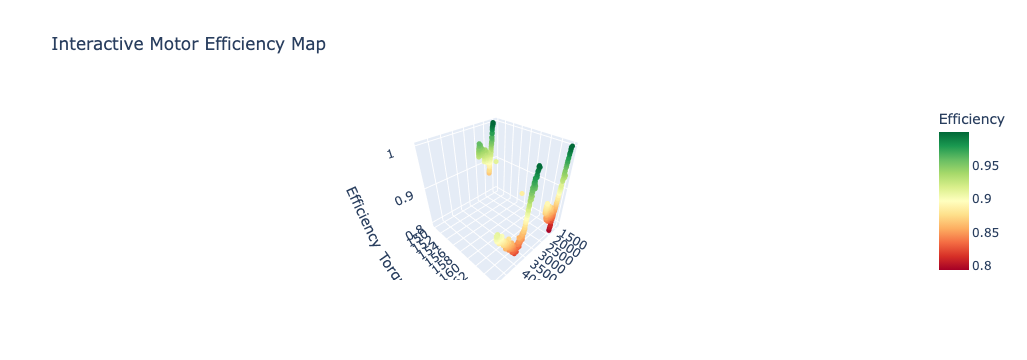

In [22]:
def plot_interactive_efficiency(combined_df):
    fig = px.scatter_3d(
        combined_df, 
        x='Car.Data.Motor.MotorRPM', 
        y='Car.Data.Inverter.InverterCalculatedTorque', 
        z='eff',
        color='eff',
        color_continuous_scale='RdYlGn',
        title="Interactive Motor Efficiency Map",
        labels={'eff': 'Efficiency', 'Car.Data.Motor.MotorRPM': 'RPM', 'Car.Data.Inverter.InverterCalculatedTorque': 'Torque (Nm)'}
    )
    
    fig.update_traces(marker=dict(size=3))
    fig.show()

plot_interactive_efficiency(combined_df)

In [14]:
motec_df.columns

NameError: name 'motec_df' is not defined

In [15]:
trim_current= motec_df[motec_df['Car.Data.Inverter.InverterDCCurrent']>0]
trim_current[trim_current['Car.Data.Inverter.InverterCalculatedTorque']>100]

NameError: name 'motec_df' is not defined

In [16]:
print(sorted_dyno_files[8])
dyno_df = pd.read_csv(f'Dyno_Data/{sorted_dyno_files[8]}', parse_dates=True)

speedramp9_pl130_manual_dhruv.csv


<Axes: >

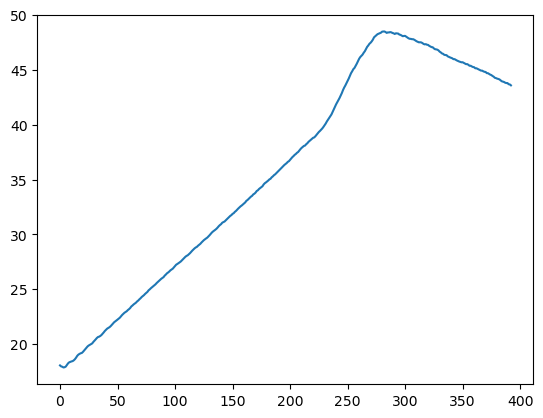

In [17]:
#(dyno_df['Axle Speed (rpm)']*38/11).
(dyno_df['Axle Torque (Nm)'] * 2 * np.pi * dyno_df['Axle Speed (rpm)'] / 60 / 1000).plot()

In [18]:
print(motec_sorted[8])
df_test = pd.read_csv(f'Motec_Data/CSV Export/{motec_sorted[8]}', header=8)

# drop the units row
df_test = df_test.iloc[1:].reset_index(drop=True)

dyno_arvo_shudderfix_andlowrpmspeedramp_9.csv


/var/folders/hk/kwysyfbx16v885w2xpzqxp5m0000gn/T/ipykernel_53304/3496481642.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(f'Motec_Data/CSV Export/{motec_sorted[8]}', header=8)


In [ ]:
voltage_col = 'Car.Data.Inverter.InverterDCVoltage'
current_col = 'Car.Data.Inverter.InverterDCCurrent'
df_test['Battery Power (kW)'] = (motec_df[voltage_col] * motec_df[current_col] / (100000))

df_test['Battery Power (kW)'].plot()